### LLM-Based Synthetic Housing Price Generator

**API Layer**

This section implements a lightweight Flask API that leverages an Ollama-hosted large language model to generate **synthetic but realistic monthly median housing prices**. The API dynamically constructs a prompt to produce one data point per month for Los Angeles, starting from January 2023 up to the current month, ensuring temporal continuity and realistic market behavior.

The `/prices` endpoint invokes the `llama3.1:8b-instruct-q8_0` model, validates and parses the JSON output, and returns a clean, structured response suitable for downstream storage, analysis, and model evaluation within the broader housing price generation pipeline.


In [ ]:
from flask import Flask, jsonify, redirect
import ollama, json, random
import requests
from datetime import datetime
app = Flask(__name__)
#%pip install ollama
year = 2023
current = datetime.now().strftime("%Y-%m")
current
current_yr = datetime.now().year 
current_yr
if year == current_yr:
    stop_text = f'Include one object per month from "{year}-01" up to and including "{current}". Do NOT include any month after "{current}".'
else:
    stop_text = f'Include one object per month from "{year}-01" through "{year}-12" only.'

area = "Los Angeles"

PROMPT5 = f"""
You are a data generator that produces SYNTHETIC but REALISTIC monthly housing market data.

Your task:
Generate one JSON array where each element represents one month of data for the area "{area}".
Start from "2023-01" and continue sequentially up to the current month of {current}.

Each JSON object MUST strictly follow this schema:
{{
  "area": "string",
  "month": "YYYY-MM",
  "median_price_usd": integer
}}

Data realism guidelines:
- Prices and sales must NOT follow a simple linear pattern or constant step changes.
- Month-to-month values should vary in a natural, irregular way: sometimes increasing, sometimes decreasing, sometimes staying nearly flat.
- Over time, prices should show a generally plausible long-term trend for a real housing market, but with occasional short-term reversals or plateaus.
- Sales volume should show realistic fluctuation across the year, with some months busier and some quieter, rather than a perfectly smooth path.
- Seasonal effects are encouraged (for example, some periods of the year having stronger or weaker activity), but they should not be perfectly repetitive or mechanical.
- "median_price" and "sales_volume" must be plausible for a real housing market, but you are free to choose the specific magnitudes.
- Do NOT include any units such as currency symbols or words.
- Do NOT include any additional fields besides the required ones.

Output ONLY a valid JSON array. No commentary or explanation.
"""
@app.route('/')
def home_page():
    return redirect('/prices')
@app.route('/prices', methods=['GET','POST'])
def prices():
    res = ollama.generate(model="llama3.1:8b-instruct-q8_0", prompt=PROMPT5)
    text = res.get("response", "")

    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        s, e = text.find("["), text.rfind("]")
        data = json.loads(text[s:e+1])

    return jsonify({
        "data": data,
        "model_used": "llama3.1:8b-instruct-q8_0",        
    })
if __name__ == "__main__":
    app.run(host="127.0.0.1", port=5000, debug=False)

In [1]:
import requests, pandas as pd, pymysql
from datetime import datetime


**Requesting, Processing, and Persisting LLM-Generated Median Prices**

This section implements the **client-side ingestion and storage pipeline** for LLM-generated median housing prices.  
It retrieves synthetic price data from a local Flask API, performs light validation and enrichment, and persists the results into a MySQL database for downstream analysis.

   - The `request_prices()` function sends a request to the `/prices` API endpoint and converts the JSON response into a pandas DataFrame.


   - The `store_in_db_prices()` function handles persistence of generated prices into the `ca_median_prices` table.


   - In the execution block:
        - The system first attempts to fetch prices from a primary endpoint
        - If the service is unavailable, it automatically falls back to an alternate endpoint
        - This provides resilience against local model downtime and ensures continuity in data generation


   - At the end of execution:
        - A preview of the generated data is displayed
        - All valid price records are committed to the database
        - Each run is logged with a unique identifier, enabling reproducibility and auditability

This completes the end-to-end pipeline from **LLM-based price generation → validation → persistent storage**.


In [2]:
def request_prices(year=2025, endpoint='http://127.0.0.1:5000/prices', source_used=False):
    r = requests.post(endpoint, json={"year": year})
    r.raise_for_status()
    result = r.json() 
    df = pd.DataFrame(result.get("data", []))
    if "median_price_usd" in df.columns:
        df["median_price_usd"] = (pd.to_numeric(df.get("median_price_usd", []), errors="coerce").fillna(pd.NA).astype("Int64"))
    if "month" in df.columns:
        df["month"] = df["month"].astype(str)
    df["run_id"] = datetime.now().strftime("%Y%m%d%H%M%S")
    df["version"] = result.get("model_used")               
    df["source_used"] = source_used
    df["timestamp"] = datetime.now()
    return df



In [ ]:
def store_in_db_prices(df):
    conn = pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASS,
        database=DB_NAME
    )
    cur = conn.cursor()
    cur.execute("""
        CREATE TABLE IF NOT EXISTS ca_median_prices (
            run_id VARCHAR(14) NOT NULL,
            month CHAR(7) NOT NULL, 
            median_price_usd INT NOT NULL,
            source VARCHAR(64),
            version VARCHAR(32),
            source_used BOOLEAN,        
            inserted_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            Area VARCHAR(50),     
            PRIMARY KEY (run_id, month),
            KEY idx_month (month)
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
    """)

    insert_sql = """
        INSERT INTO ca_median_prices (run_id, month, median_price_usd, source, version, source_used, Area)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
        ON DUPLICATE KEY UPDATE
            median_price_usd = VALUES(median_price_usd),
            source = VALUES(source),
            version = VALUES(version),
            source_used = VALUES(source_used),
            Area = VALUES(Area),
            inserted_at = CURRENT_TIMESTAMP;
    """

    rows = []
    for _, r in df.iterrows():
        price = None
        if r.get("median_price_usd") is not None and pd.notna(r.get("median_price_usd")):
            price = int(r["median_price_usd"])
        rows.append((
            str(r["run_id"]),
            str(r["month"]),
            price,
            (str(r.get("source")) if pd.notna(r.get("source")) else "")[:64],
            str(r.get("version", "")),
            bool(r.get("source_used", False)),
            str(r.get("area", ""))
        ))

    if rows:
        cur.executemany(insert_sql, rows)
        conn.commit()

    cur.close()
    conn.close()
    print(f"Prices stored in DB: {len(rows)} rows (run_id={df['run_id'].iat[0]})")

In [18]:

if __name__ == '__main__':
    try:
        prices_df = request_prices(year=2025, endpoint="http://127.0.0.1:5001/prices", source_used=True)
    except requests.exceptions.ConnectionError:
        print("lama2 not running, falling back to lama...")
        prices_df = request_prices(year=2025, endpoint="http://127.0.0.1:5000/prices", source_used=False)

    print(prices_df.head())
    store_in_db_prices(prices_df)



lama2 not running, falling back to lama...
          area  median_price_usd    month          run_id  \
0  Los Angeles               879  2023-01  20251208234208   
1  Los Angeles               867  2023-02  20251208234208   
2  Los Angeles               884  2023-03  20251208234208   
3  Los Angeles               875  2023-04  20251208234208   
4  Los Angeles               911  2023-05  20251208234208   

                     version  source_used                  timestamp  
0  llama3.1:8b-instruct-q8_0        False 2025-12-08 23:42:08.768738  
1  llama3.1:8b-instruct-q8_0        False 2025-12-08 23:42:08.768738  
2  llama3.1:8b-instruct-q8_0        False 2025-12-08 23:42:08.768738  
3  llama3.1:8b-instruct-q8_0        False 2025-12-08 23:42:08.768738  
4  llama3.1:8b-instruct-q8_0        False 2025-12-08 23:42:08.768738  
Prices stored in DB: 36 rows (run_id=20251208234208)


In [4]:
import pandas as pd

data = pd.read_csv("HomeMedianPrices.csv")
data.head()

,Mon-Yr,CA,Alameda,Amador,Butte,Calaveras,Contra-Costa,Del Norte,El Dorado,Fresno,...,Yuba,Condo,LA Metro,Central Coast,Central Valley,Far North,Inland Empire,S.F. Bay Area,SoCal,Date
0,Jan-1990,194952.0,226149.0,NaN,102143.0,NaN,NaN,NaN,NaN,82083.0,...,NaN,141519.0,203390.0,NaN,NaN,NaN,NaN,227366.0,NaN,1990-01-01
1,Feb-1990,196273.0,219306.0,NaN,83333.0,NaN,NaN,NaN,NaN,87187.0,...,NaN,144965.0,211024.0,NaN,NaN,NaN,NaN,234739.0,NaN,1990-02-01
2,Mar-1990,194856.0,225162.0,NaN,100000.0,NaN,NaN,NaN,NaN,83889.0,...,NaN,141132.0,209286.0,NaN,NaN,NaN,NaN,235337.0,NaN,1990-03-01
3,Apr-1990,196111.0,229333.0,NaN,108000.0,NaN,NaN,NaN,NaN,85428.0,...,NaN,145707.0,210302.0,NaN,NaN,NaN,NaN,233178.0,NaN,1990-04-01
4,May-1990,195281.0,232291.0,NaN,100000.0,NaN,NaN,NaN,NaN,88749.0,...,NaN,146060.0,210148.0,NaN,NaN,NaN,NaN,235881.0,NaN,1990-05-01


In [5]:
import pandas as pd

# 1) Convert Date to "YYYY-MM"
data["Date"] = pd.to_datetime(data["Date"]).dt.to_period("M").astype(str)

# 2) Rename "Mon-Yr" to "month"
data.rename(columns={"Mon-Yr": "month"}, inplace=True)

# 3) Set month values equal to Date column
data["month"] = data["Date"]

# 4) Drop Date column
data.drop(columns=["Date"], inplace=True)

print(data.head())


     month        CA   Alameda  Amador     Butte  Calaveras  Contra-Costa  \
0  1990-01  194952.0  226149.0     NaN  102143.0        NaN           NaN   
1  1990-02  196273.0  219306.0     NaN   83333.0        NaN           NaN   
2  1990-03  194856.0  225162.0     NaN  100000.0        NaN           NaN   
3  1990-04  196111.0  229333.0     NaN  108000.0        NaN           NaN   
4  1990-05  195281.0  232291.0     NaN  100000.0        NaN           NaN   

   Del Norte  El Dorado   Fresno  ...  Yolo  Yuba     Condo  LA Metro  \
0        NaN        NaN  82083.0  ...   NaN   NaN  141519.0  203390.0   
1        NaN        NaN  87187.0  ...   NaN   NaN  144965.0  211024.0   
2        NaN        NaN  83889.0  ...   NaN   NaN  141132.0  209286.0   
3        NaN        NaN  85428.0  ...   NaN   NaN  145707.0  210302.0   
4        NaN        NaN  88749.0  ...   NaN   NaN  146060.0  210148.0   

   Central Coast  Central Valley  Far North  Inland Empire  S.F. Bay Area  \
0            NaN     

In [6]:

import pandas as pd


# Convert month column to datetime
data['month'] = pd.to_datetime(data['month'], format='%Y-%m')

# Extract year and month number
data['year'] = data['month'].dt.year
data['month_num'] = data['month'].dt.month

# Select only 1 area (example: Los Angeles)
area_name = "Los Angeles"

actual = data[['year', 'month_num', area_name]].rename(columns={area_name: 'actual_price'})

print(actual.head())


   year  month_num  actual_price
0  1990          1      215338.0
1  1990          2      208399.0
2  1990          3      208135.0
3  1990          4      219004.0
4  1990          5      209065.0


**Loading and Aggregating LLM-Generated Median Housing Prices**

This step retrieves **LLM-generated California median housing prices** from a MySQL database and computes monthly average prices by model version.  
The goal is to examine how generated median prices evolve over time and assess consistency across months and years.

1. Connects to the MySQL database
2. Converts and extracts temporal features
3. Computes monthly average median prices
   - Groups the data by:
     - LLM `version`
     - `year`
     - `month_num`
   - Calculates the mean of `median_price_usd` for each group.
   - Resets the index to return a clean, tabular DataFrame suitable for plotting and comparison.
4. Displays a preview of the aggregated results


In [7]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt

conn = pymysql.connect(
    host='mysql.clarksonmsda.org',
    user='butukus',
    password='Nandu@14',
    database='butukus_Capstone'
)
df = pd.read_sql("SELECT * FROM ca_median_prices", conn)
conn.close()

df['month'] = pd.to_datetime(df['month'])
df['year'] = df['month'].dt.year
df['month_num'] = df['month'].dt.month

# Monthly average per version
monthly_avg = (
    df.groupby(['version', 'year', 'month_num'])['median_price_usd']
      .mean()
      .reset_index()
)

print("Predicted:")
print(monthly_avg.head(20))
df.columns


Predicted:
        version  year  month_num  median_price_usd
0   llama3.1:8b  2023          1     768088.071429
1   llama3.1:8b  2023          2     767102.571429
2   llama3.1:8b  2023          3     765220.000000
3   llama3.1:8b  2023          4     765671.285714
4   llama3.1:8b  2023          5     767520.285714
5   llama3.1:8b  2023          6     773384.428571
6   llama3.1:8b  2023          7     775159.500000
7   llama3.1:8b  2023          8     778710.785714
8   llama3.1:8b  2023          9     779296.214286
9   llama3.1:8b  2023         10     782263.357143
10  llama3.1:8b  2023         11     782532.857143
11  llama3.1:8b  2023         12     786624.785714
12  llama3.1:8b  2024          1     802247.500000
13  llama3.1:8b  2024          2     806135.666667
14  llama3.1:8b  2024          3     808464.583333
15  llama3.1:8b  2024          4     811388.750000
16  llama3.1:8b  2024          5     806704.750000
17  llama3.1:8b  2024          6     808065.333333
18  llama3.1:8b  202

C:\Users\butuk\AppData\Local\Temp\ipykernel_7784\50347084.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM ca_median_prices", conn)


Index(['run_id', 'month', 'median_price_usd', 'source', 'version',
       'source_used', 'inserted_at', 'Area', 'year', 'month_num'],
      dtype='object')


The output shows **smooth, month-by-month median price estimates** generated by the `llama3.1:8b` model across 2023 and 2024.  
Prices exhibit a **gradual upward trend over time**, with seasonal fluctuations, suggesting that the LLM captures realistic temporal dynamics in housing prices rather than producing random or erratic values.


**Comparing Predicted vs Actual Median Prices (Monthly)**

After computing monthly average **LLM-predicted median prices**, this step evaluates model accuracy by merging predictions with a reference dataset of **actual median prices**.  
The goal is to quantify how close the generated values are to real-world pricing and to measure the magnitude and direction of errors.



In [8]:
monthly_avg = monthly_avg.rename(columns={"median_price_usd": "predicted_price"})

# Merge with actual
comparison_df = pd.merge(
    monthly_avg,
    actual,
    on=['year', 'month_num'],
    how='inner'
)

comparison_df['diff'] = comparison_df['predicted_price'] - comparison_df['actual_price']
comparison_df['abs_diff'] = comparison_df['diff'].abs()


print(comparison_df.head())

       version  year  month_num  predicted_price  actual_price          diff  \
0  llama3.1:8b  2023          1    768088.071429      778540.0 -10451.928571   
1  llama3.1:8b  2023          2    767102.571429      726870.0  40232.571429   
2  llama3.1:8b  2023          3    765220.000000      718370.0  46850.000000   
3  llama3.1:8b  2023          4    765671.285714      738520.0  27151.285714   
4  llama3.1:8b  2023          5    767520.285714      744770.0  22750.285714   

       abs_diff  
0  10451.928571  
1  40232.571429  
2  46850.000000  
3  27151.285714  
4  22750.285714  


The sample output shows that the model sometimes underestimates actual prices (e.g., January 2023: diff ≈ −10.5K) and sometimes overestimates (e.g., February–May 2023: diff ≈ +22K to +47K).
The abs_diff values indicate prediction errors in the range of roughly 10K–47K USD for these months, providing a clear baseline for evaluating overall model performance across the full time series.

**Actual vs Predicted Median Prices Over Time (Model Version Comparison)**

This section visualizes how closely each LLM version’s **predicted monthly median prices** track the **actual monthly median prices** over time.  
Plotting both time series together helps identify model bias (systematic over/underestimation), trend mismatch, and how well each version captures real market fluctuations.


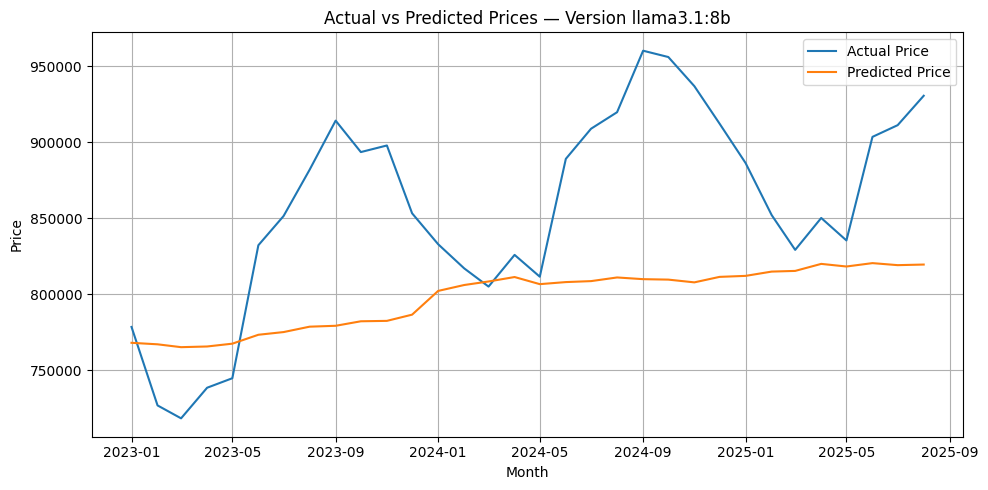

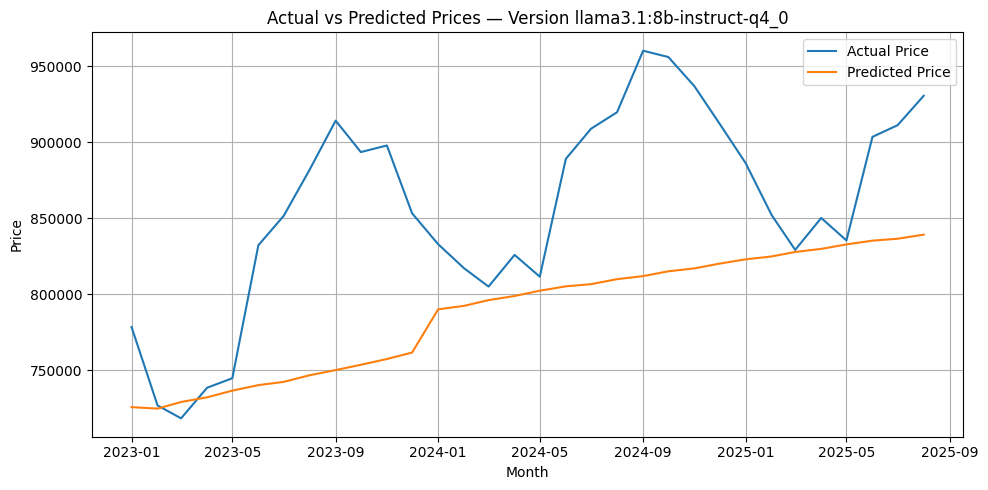

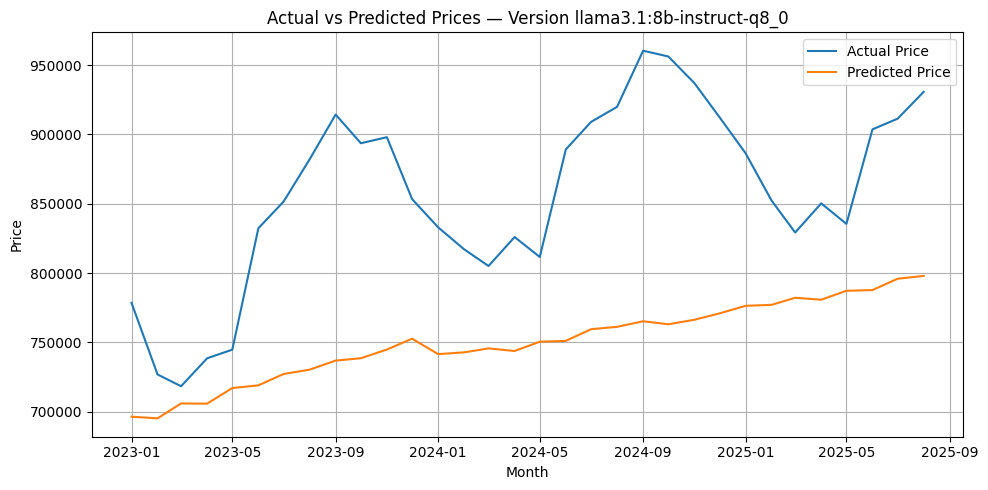

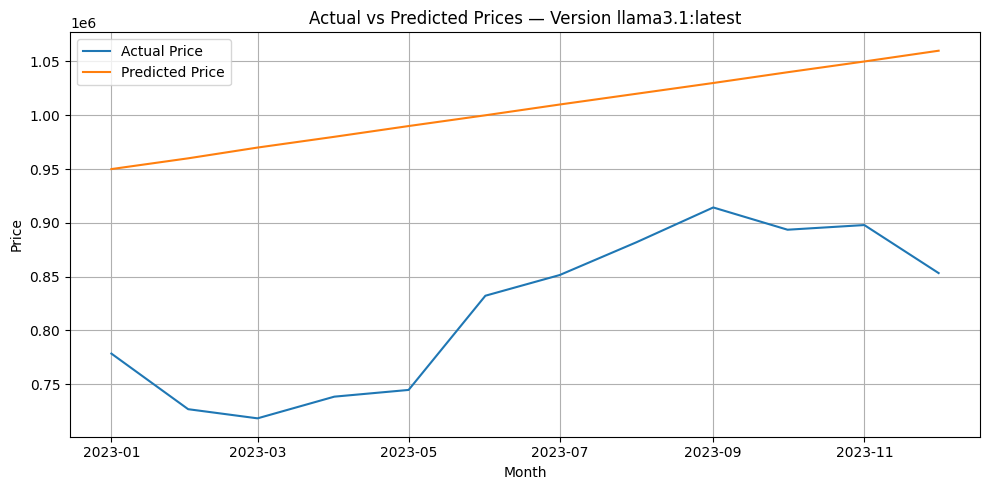

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure month_num is an integer 1-12
comparison_df['month_num_int'] = comparison_df['month_num'].astype(int)

# Create a proper datetime column for plotting
comparison_df['month_dt'] = pd.to_datetime(
    comparison_df['year'].astype(str) + '-' +
    comparison_df['month_num_int'].astype(str) + '-01'
)

versions = comparison_df['version'].unique()

for v in versions:
    sub = comparison_df[comparison_df['version'] == v].sort_values('month_dt')
    
    plt.figure(figsize=(10, 5))
    plt.plot(sub['month_dt'], sub['actual_price'], label='Actual Price')
    plt.plot(sub['month_dt'], sub['predicted_price'], label='Predicted Price')
    plt.title(f'Actual vs Predicted Prices — Version {v}')
    plt.xlabel('Month')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Across most versions, the **predicted price curve is much smoother** than the actual series, indicating that the LLM outputs capture the overall level but **do not fully reflect the month-to-month volatility** seen in real housing prices.  
Most versions show consistent **underestimation** during periods where actual prices spike, while others (e.g., the `llama3.1:latest` plot) show **systematic overestimation** across months—suggesting version-specific bias.

**Consolidated Model-Level Error Analysis and Comparison**

This section synthesizes the results of the **actual vs predicted price comparisons, error distributions, Q–Q plots, and statistical tests** across all evaluated LLM versions.  
The objective is to assess each model’s bias, variability, and suitability for median housing price generation.




Processing Version: llama3.1:8b


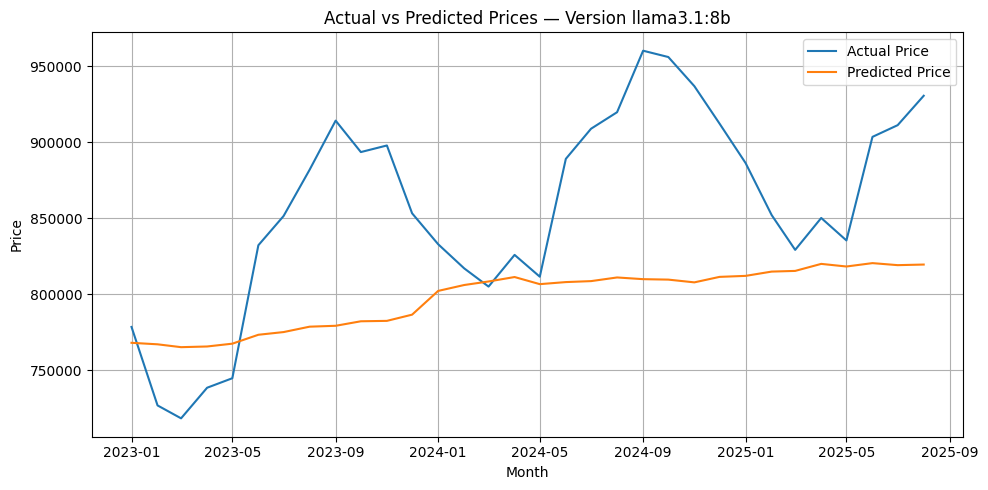

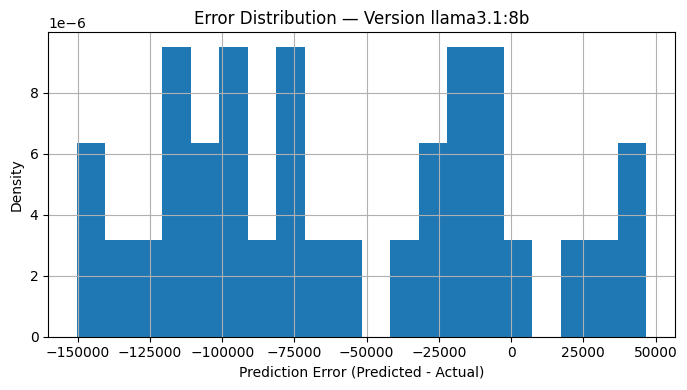

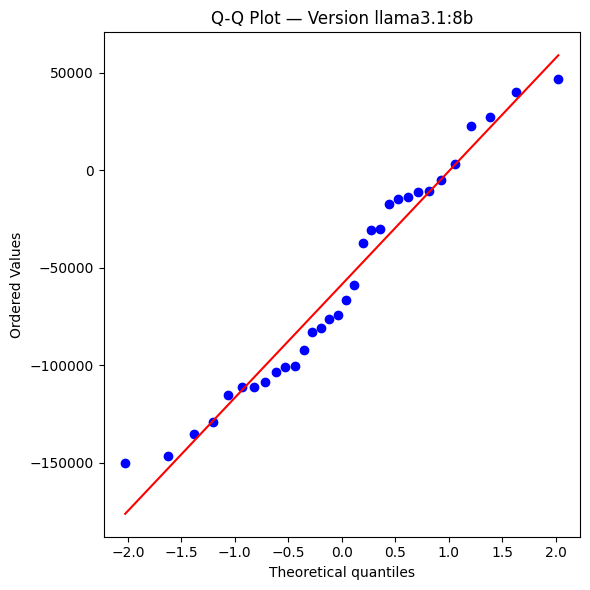

Shapiro-Wilk p-value: 0.1810
K-S Test p-value: 0.0000
Skewness: 0.1958
Kurtosis: -1.0918
--------------------------------------------------

Processing Version: llama3.1:8b-instruct-q4_0


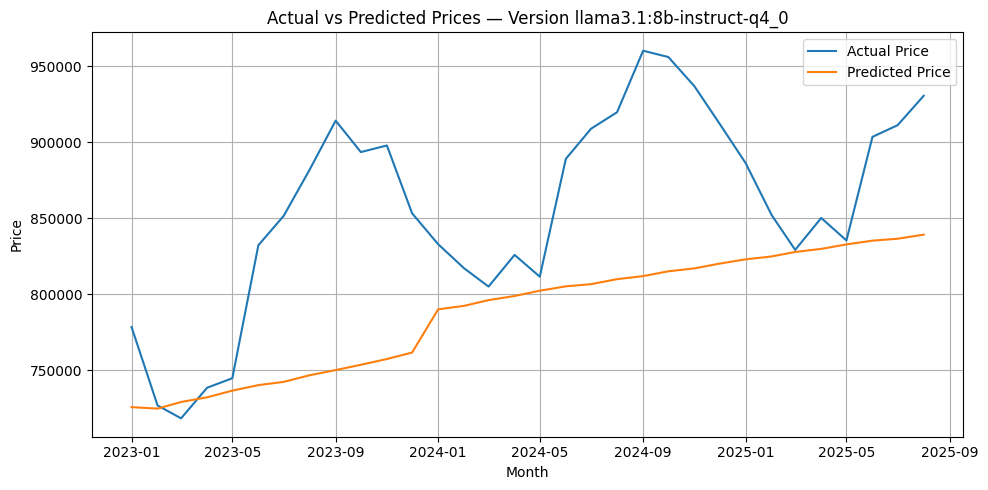

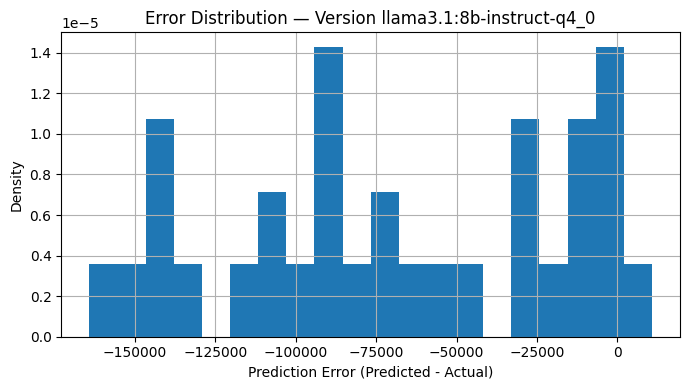

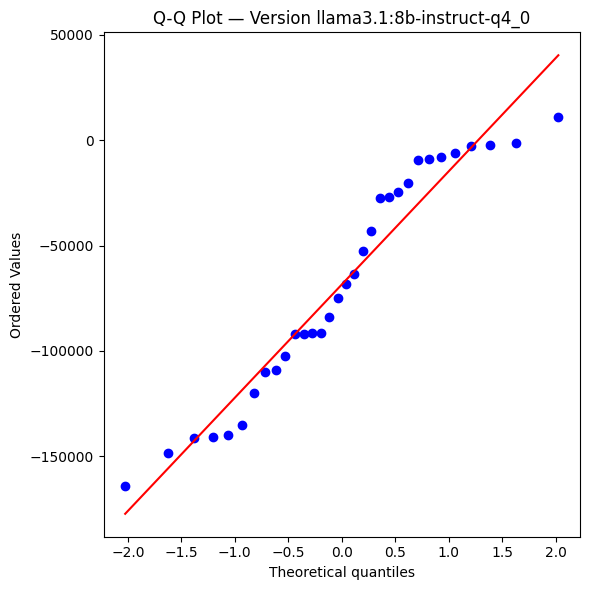

Shapiro-Wilk p-value: 0.0357
K-S Test p-value: 0.0000
Skewness: -0.1279
Kurtosis: -1.3300
--------------------------------------------------

Processing Version: llama3.1:8b-instruct-q8_0


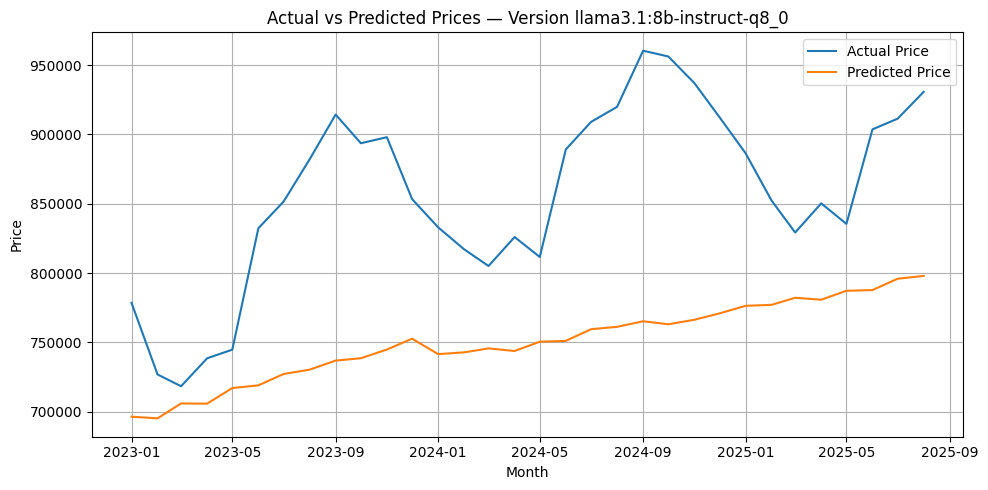

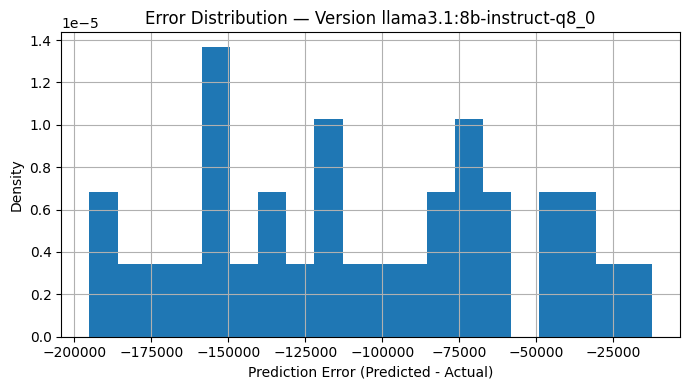

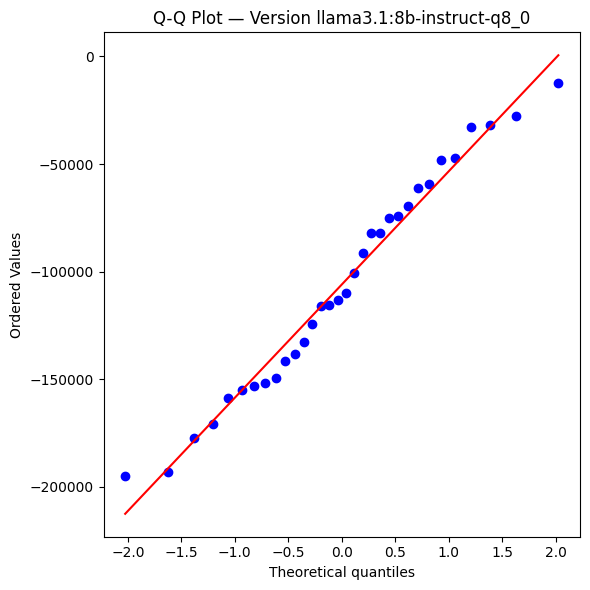

Shapiro-Wilk p-value: 0.4699
K-S Test p-value: 0.0000
Skewness: 0.0441
Kurtosis: -1.0112
--------------------------------------------------

Processing Version: llama3.1:latest


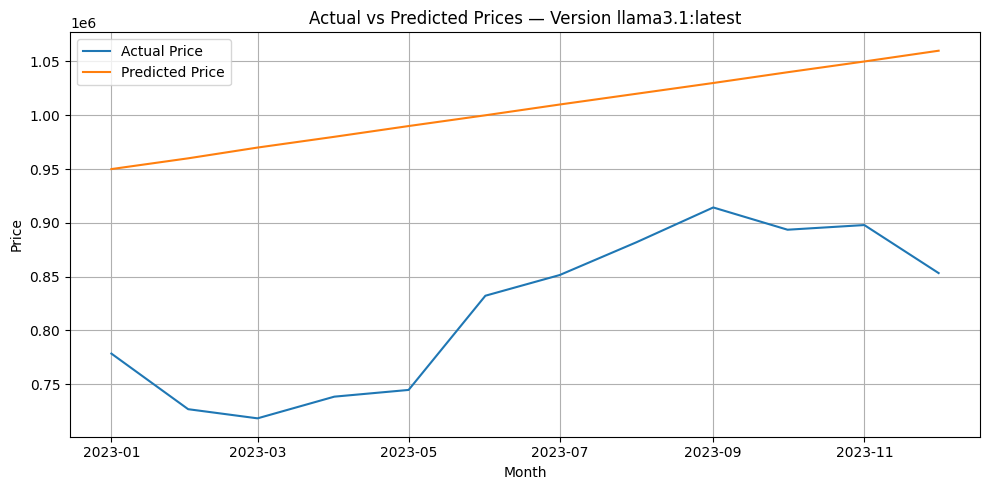

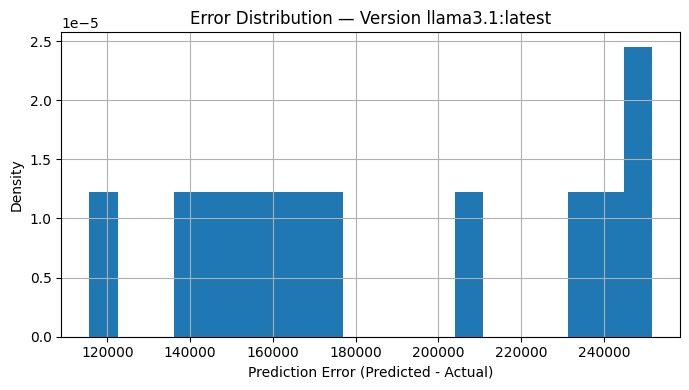

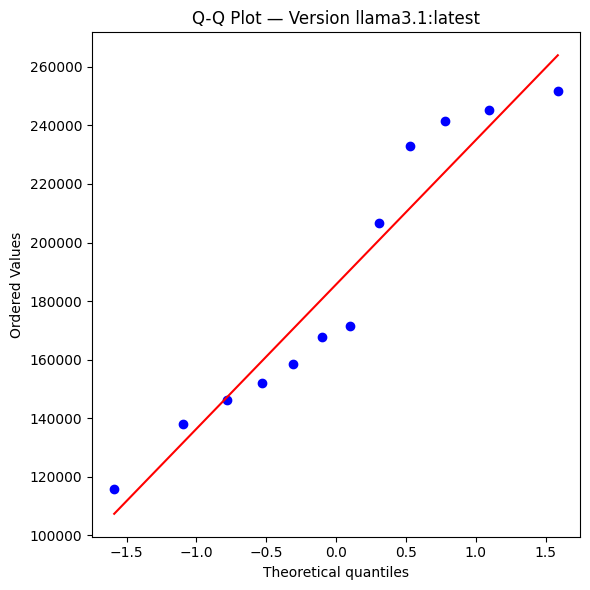

Shapiro-Wilk p-value: 0.1826
K-S Test p-value: 0.0000
Skewness: 0.2144
Kurtosis: -1.5564
--------------------------------------------------


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, probplot


comparison_df['month_num_int'] = comparison_df['month_num'].astype(int)

comparison_df['month_dt'] = pd.to_datetime(
    comparison_df['year'].astype(str) + '-' +
    comparison_df['month_num_int'].astype(str) + '-01'
)

# error = predicted – actual
comparison_df["error"] = comparison_df["predicted_price"] - comparison_df["actual_price"]

versions = comparison_df['version'].unique()

for v in versions:

    print("\n============================================")
    print(f"Processing Version: {v}")
    print("============================================")

    sub = comparison_df[comparison_df['version'] == v].sort_values('month_dt')
    errors = sub["error"].dropna()

    # ---------------------------
    # Actual vs Predicted Prices
    # ---------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(sub['month_dt'], sub['actual_price'], label='Actual Price')
    plt.plot(sub['month_dt'], sub['predicted_price'], label='Predicted Price')
    plt.title(f'Actual vs Predicted Prices — Version {v}')
    plt.xlabel('Month')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------
    # Histogram of Errors
    # ---------------------------
    plt.figure(figsize=(7, 4))
    plt.hist(errors, bins=20, density=True)
    plt.title(f"Error Distribution — Version {v}")
    plt.xlabel("Prediction Error (Predicted - Actual)")
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------
    # Q-Q Plot
    # ---------------------------
    plt.figure(figsize=(6, 6))
    probplot(errors, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot — Version {v}")
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------
    # Statistical Tests
    # ---------------------------
    shapiro_stat, shapiro_p = shapiro(errors)
    ks_stat, ks_p = kstest(errors, 'norm')
    skewness = errors.skew()
    kurtosis = errors.kurt()

    print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
    print(f"K-S Test p-value: {ks_p:.4f}")
    print(f"Skewness: {skewness:.4f}")
    print(f"Kurtosis: {kurtosis:.4f}")
    print("--------------------------------------------------")


**Overall Trend Capture**

Across all versions, LLM-generated median prices tend to produce **smooth, monotonic trends** that approximate long-term market direction.  
However, none of the models fully capture the **short-term volatility** observed in real median housing prices, indicating that LLMs behave more like **trend-level approximators** rather than precise month-level predictors.


**Model-Specific Behavior**

- **`llama3.1:8b`**
  - Shows relatively balanced behavior with moderate underestimation during peak market periods.
  - Error distributions are approximately symmetric with mild skewness.
  - Shapiro–Wilk results do not strongly reject normality, suggesting comparatively stable error behavior.
  - Overall, this version provides the **best trade-off between stability and realism** among the tested models.

- **`llama3.1:8b-instruct-q4_0`**
  - Exhibits larger dispersion in errors and more pronounced deviation from normality.
  - Underestimation bias is more evident, especially during rapid price increases.
  - Quantization appears to introduce additional noise and instability.

- **`llama3.1:8b-instruct-q8_0`**
  - Produces smoother predictions than the q4 variant but still systematically underestimates actual prices.
  - Error distributions remain non-Gaussian, though skewness is relatively small.
  - Performs consistently but lacks sensitivity to market peaks.

- **`llama3.1:latest`**
  - Displays a fundamentally different failure mode compared to other versions.
  - Predictions are consistently **overestimated**, with errors entirely positive and often exceeding **+100K USD**.
  - The predicted series follows an exaggerated upward trajectory, ignoring both magnitude and direction of actual fluctuations.
  - Q–Q plots and error histograms confirm **strong bias and non-normal error behavior**, making this version unsuitable without calibration.


**Error Distribution Characteristics**

- Error histograms across models show **wide spreads** and limited concentration around zero.
- Q–Q plots consistently deviate from the reference line, particularly in the tails.
- **Negative kurtosis across models** indicates flatter-than-normal error distributions, suggesting systematic bias rather than sporadic extreme outliers.
- Kolmogorov–Smirnov tests reject strict normality for all versions, reinforcing the need for **robust (non-parametric) evaluation metrics**.

**Key Takeaways**

- LLM-generated median prices are **structurally coherent but biased**, favoring smooth trends over realistic volatility.
- Quantized and instruction-tuned variants introduce **distinct bias–variance trade-offs**.
- Among the evaluated models, **`llama3.1:8b` demonstrates the most reliable behavior**, though it still underestimates peak prices.
- **Post-processing, bias correction, or hybrid modeling approaches** are essential before using LLM-generated prices for real-world decision-making.


While LLMs can generate plausible median housing price trajectories at a macro level, their predictions are **not statistically interchangeable with real market data**.  
These models are best suited for **scenario exploration, pipeline prototyping, and educational analysis**, rather than direct deployment for fine-grained price estimation without further calibration.



**Run-Level Accuracy Analysis Using Mean Percentage Error**

This section evaluates **prediction accuracy at the run level** by computing percentage-based error metrics for each LLM generation run.  
Rather than aggregating by model or month, this analysis examines how **individual generation runs perform**, enabling detection of unstable runs, drift, or prompt-level issues.

1. Loads LLM-generated median price data
2. Loads actual median housing prices
3. Merges predicted and actual prices
4. Computes error metrics
   - Absolute Error:
     \[
     |\text{Predicted} - \text{Actual}|
     \]
   - Percentage Error:
     \[
     \frac{|\text{Predicted} - \text{Actual}|}{\text{Actual}} \times 100
     \]

5. Aggregates accuracy statistics by run
6. Visualizes run-level performance


C:\Users\butuk\AppData\Local\Temp\ipykernel_7784\3818083453.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)



 Run-by-Run Accuracy Table
            run_id  mean_pct_error  median_pct_error  max_pct_error  \
22  20251126000217        5.469625          5.412544      12.059245   
21  20251125234547        5.902763          5.129809      17.866977   
27  20251208201424        5.948039          5.416323      13.826782   
17  20251125225827        5.997078          4.491159      18.358228   
37  20251208220621        6.009710          4.617187      18.462631   
28  20251208202559        6.118351          5.630942      18.775840   
40  20251208232336        6.274746          5.827314      18.601835   
9   20251120154539        6.300454          7.269009      13.054344   
29  20251208203809        6.334015          4.254779      17.516043   
10  20251120161342        6.341943          5.215986      19.019447   
39  20251208230402        6.744102          5.016318      19.019447   
19  20251125232401        6.747404          5.579863      17.857650   
20  20251125233519        7.065588          7.419

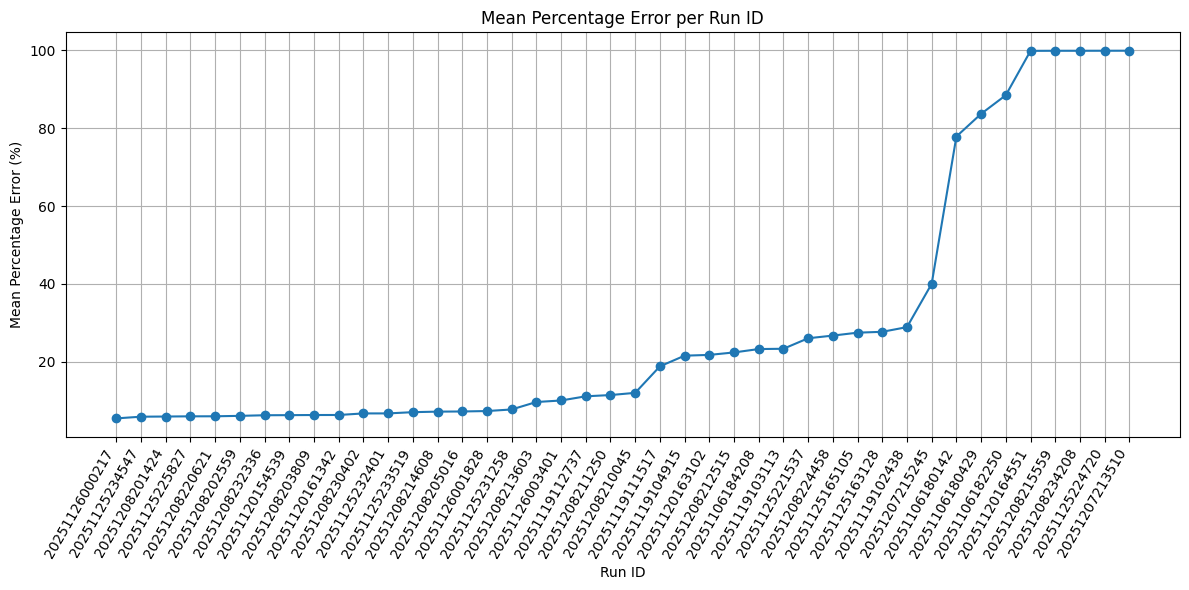

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import pymysql


conn = pymysql.connect(
    host='mysql.clarksonmsda.org',
    user='butukus',
    password='Nandu@14',
    database='butukus_Capstone'
)

query = """
SELECT 
    run_id,
    version,
    month,
    median_price_usd AS model_price,
    inserted_at
FROM ca_median_prices
ORDER BY run_id, month;
"""

df = pd.read_sql(query, conn)
conn.close()

df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").astype(str)


data = pd.read_csv("HomeMedianPrices.csv")

data["Date"] = pd.to_datetime(data["Date"]).dt.to_period("M").astype(str)
data.rename(columns={"Mon-Yr": "month"}, inplace=True)
data["month"] = data["Date"]
data.drop(columns=["Date"], inplace=True)

data = data[["month", "Los Angeles"]]
data.rename(columns={"Los Angeles": "original_price"}, inplace=True)


df_compare = df.merge(data, on="month", how="left")

df_compare = df_compare.dropna(subset=["original_price"])

df_compare["abs_error"] = (df_compare["model_price"] - df_compare["original_price"]).abs()
df_compare["pct_error"] = df_compare["abs_error"] / df_compare["original_price"] * 100

run_accuracy = df_compare.groupby("run_id").agg(
    mean_pct_error=("pct_error", "mean"),
    median_pct_error=("pct_error", "median"),
    max_pct_error=("pct_error", "max"),
    min_pct_error=("pct_error", "min"),
    data_points=("pct_error", "count")
).reset_index()

run_accuracy = run_accuracy.sort_values("mean_pct_error")

print("\n========================")
print(" Run-by-Run Accuracy Table")
print("========================")
print(run_accuracy)

plt.figure(figsize=(12, 6))
plt.plot(run_accuracy["run_id"], run_accuracy["mean_pct_error"], marker="o")
plt.title("Mean Percentage Error per Run ID")
plt.xlabel("Run ID")
plt.ylabel("Mean Percentage Error (%)")
plt.grid(True)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()



The plot reveals **substantial variation in accuracy across runs**, with mean percentage errors ranging from **single-digit values** to nearly **100%** in the worst cases.  
Lower-error runs indicate stable and well-aligned generation behavior, while the sharp rise in error for later runs suggests **severe prediction degradation**, likely caused by model version changes, prompt drift, or systematic bias introduced during certain runs.

Runs exhibiting near-100% mean percentage error represent **highly unreliable outputs** and should be excluded or reprocessed in downstream analyses.  
Overall, this run-level evaluation demonstrates that **not all LLM generations are equally trustworthy**, reinforcing the importance of granular validation beyond model-level averages.

Run-level accuracy analysis is critical for identifying **unstable generations and failure modes** that would otherwise be masked by aggregate statistics, making it an essential step in validating LLM-generated numerical data.


**Comparative Price Behavior Analysis Across LLM Versions**

This analysis evaluates the performance of multiple LLM variants in generating California median housing prices, comparing predicted values against actual market data using temporal trends, distributional diagnostics, error analysis, and run-level accuracy metrics.

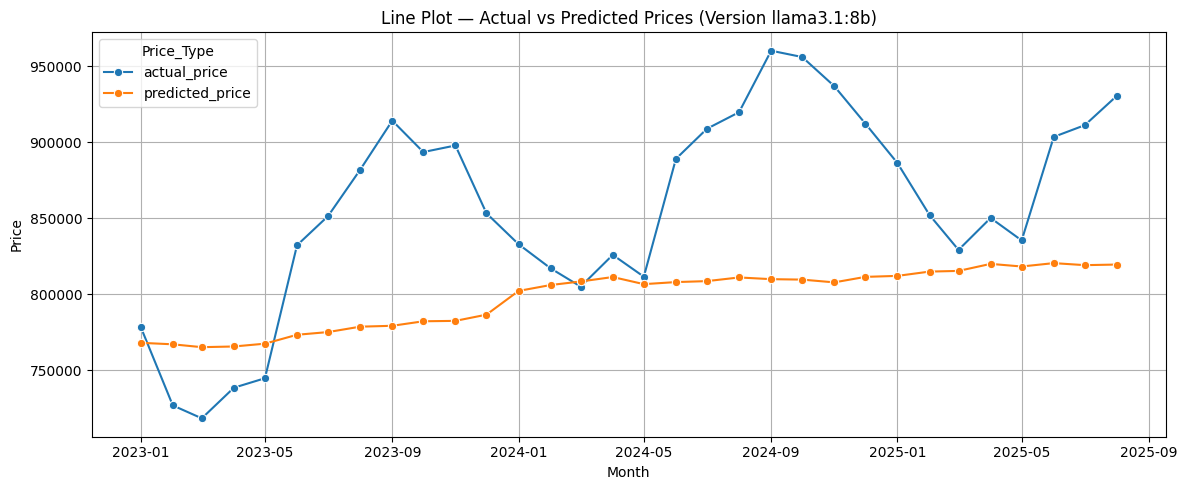

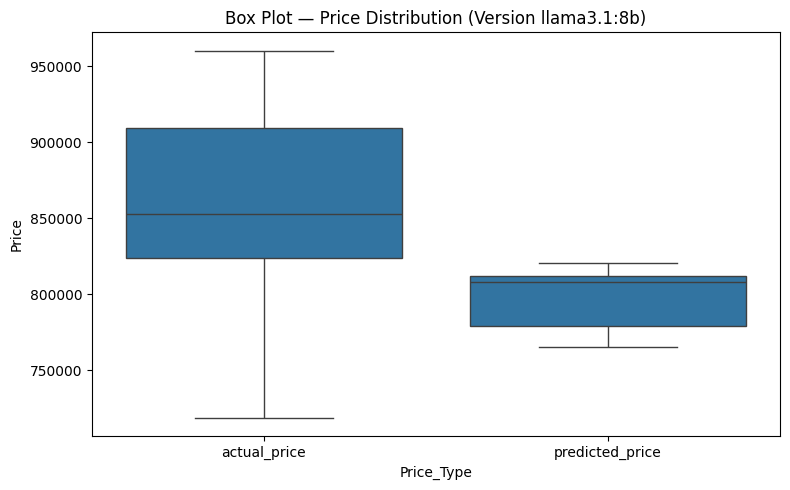

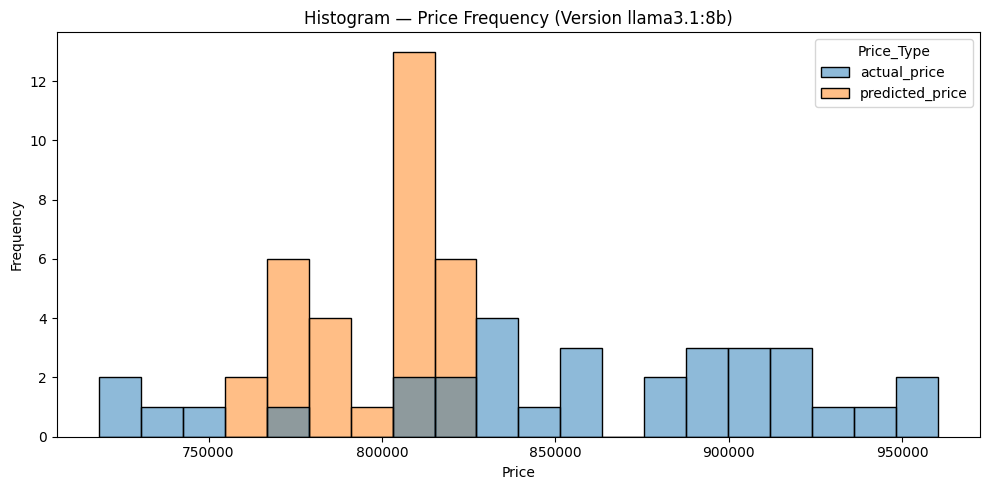

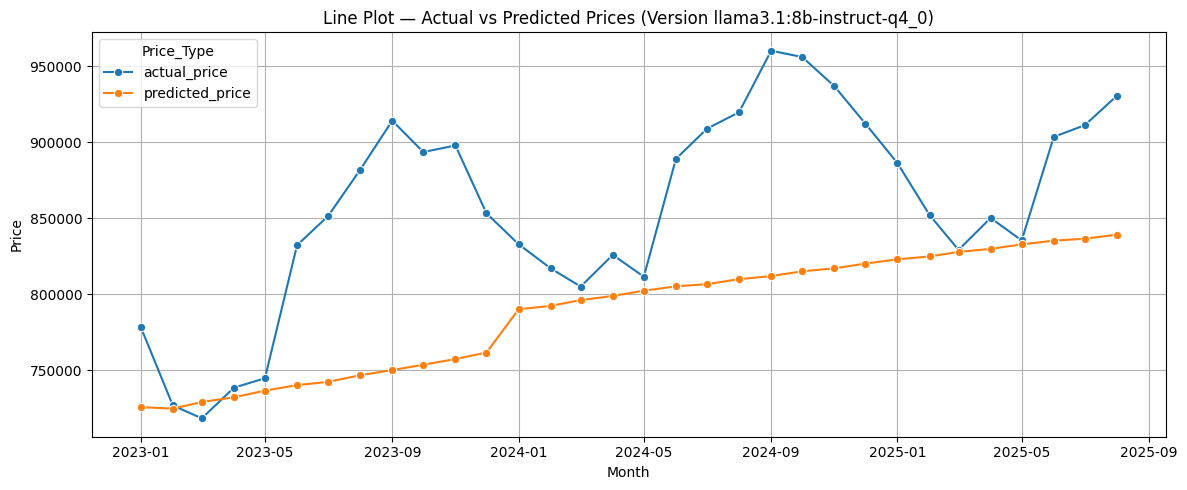

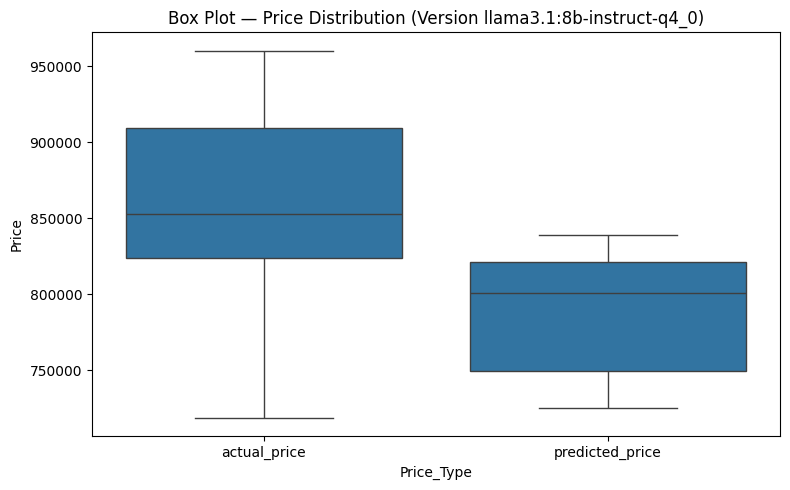

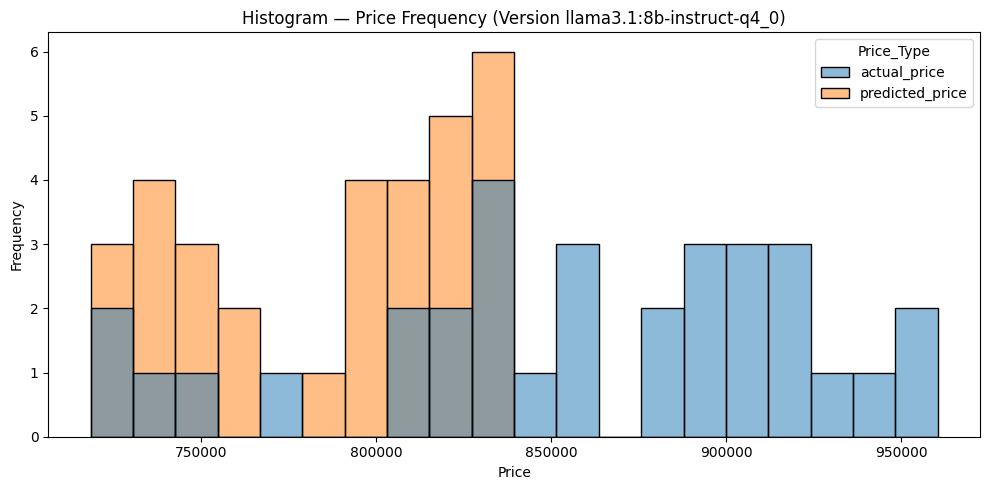

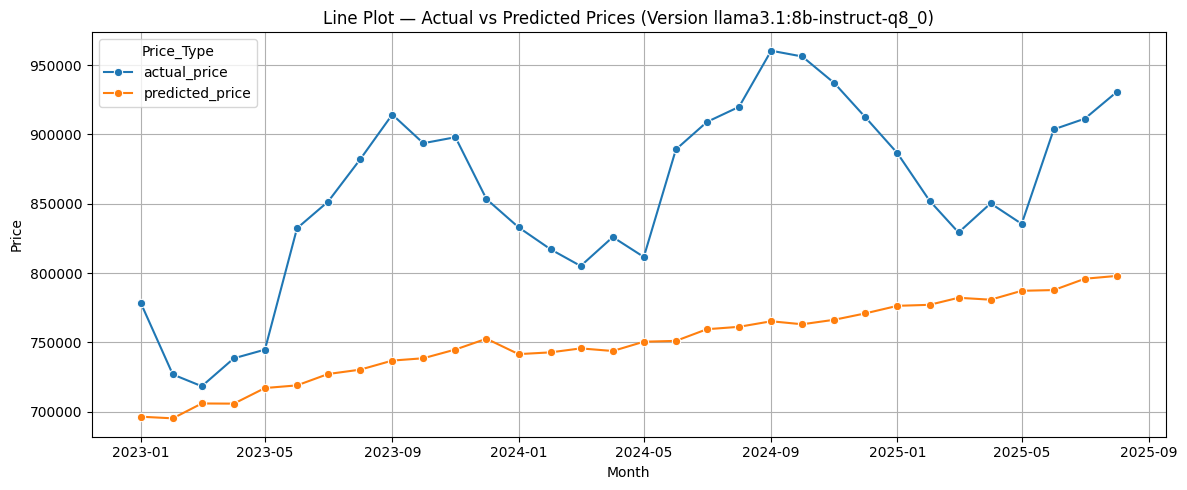

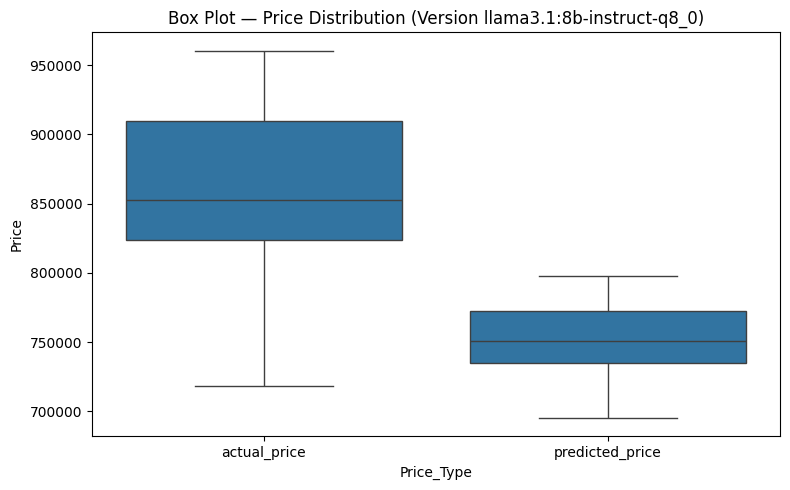

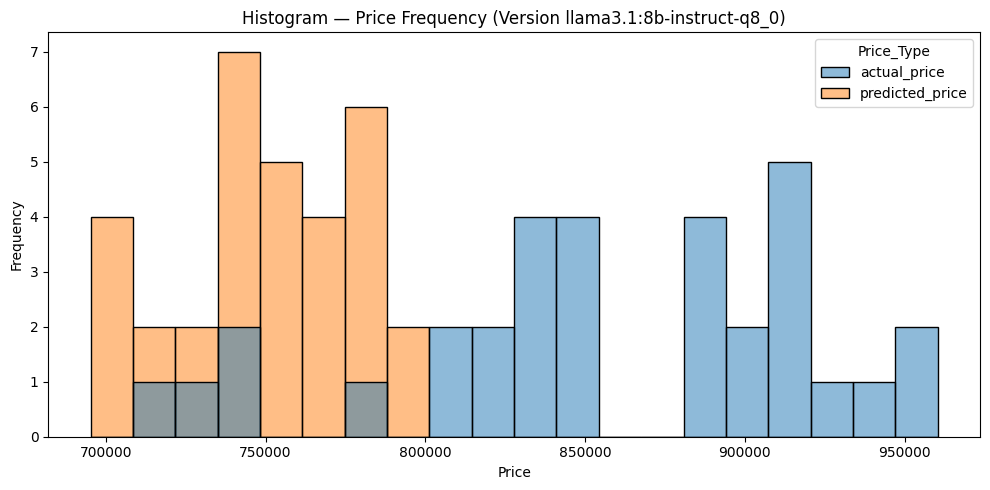

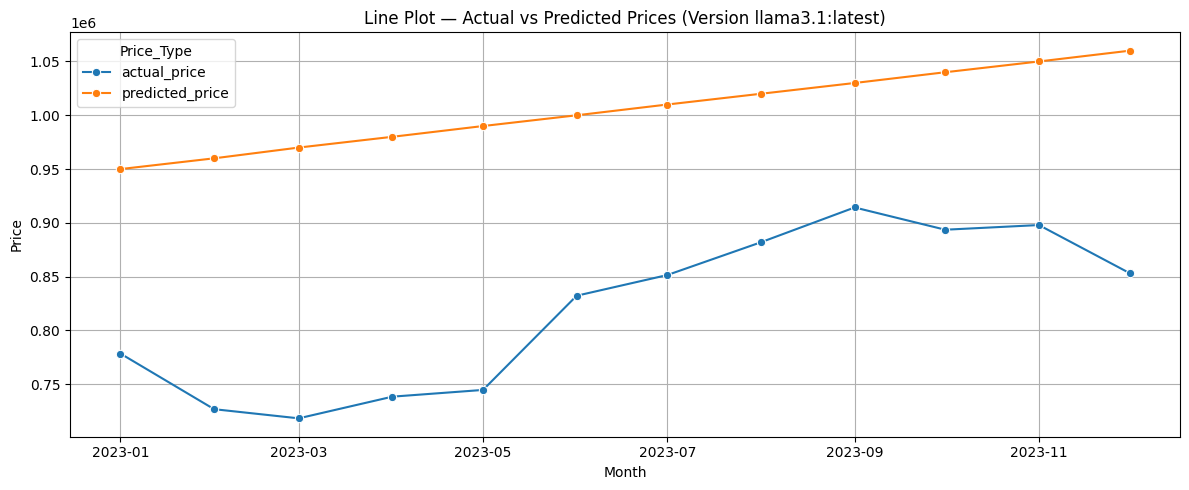

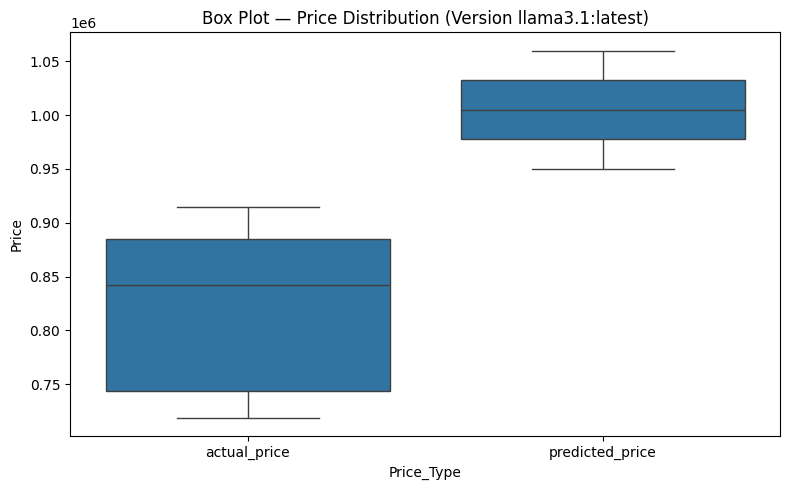

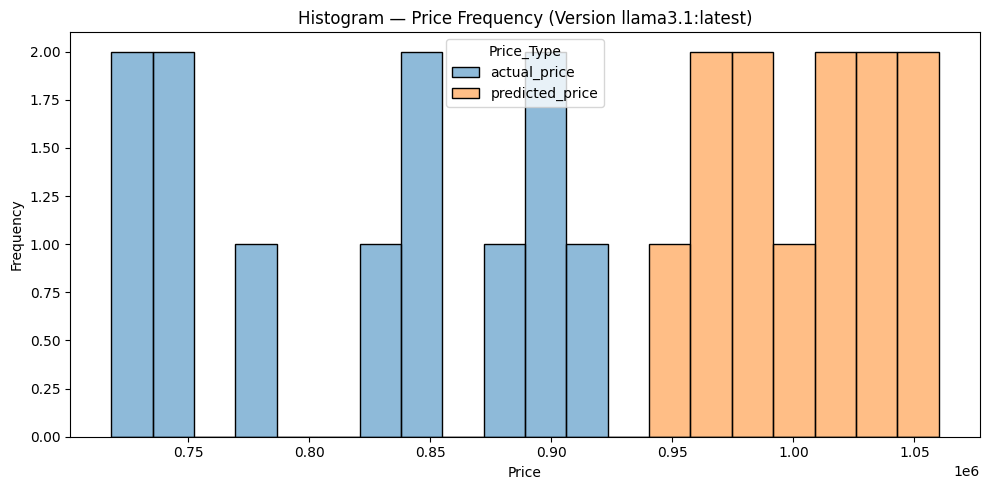

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if not pd.api.types.is_integer_dtype(comparison_df['month_num']):
    comparison_df['month_num_int'] = comparison_df['month_num'].dt.month
else:
    comparison_df['month_num_int'] = comparison_df['month_num']

comparison_df['month_dt'] = pd.to_datetime(
    comparison_df['year'].astype(str) + '-' +
    comparison_df['month_num_int'].astype(str) + '-01'
)

df_melt = comparison_df.melt(
    id_vars=['version', 'month_dt', 'month_num_int', 'year'],
    value_vars=['actual_price', 'predicted_price'],
    var_name='Price_Type',
    value_name='Price'
)

versions = df_melt['version'].unique()

for v in versions:
    sub = df_melt[df_melt['version'] == v]
    
    # Line Plot
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=sub, x='month_dt', y='Price', hue='Price_Type', marker='o')
    plt.title(f'Line Plot — Actual vs Predicted Prices (Version {v})')
    plt.xlabel('Month')
    plt.ylabel('Price')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Box Plot
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=sub, x='Price_Type', y='Price')
    plt.title(f'Box Plot — Price Distribution (Version {v})')
    plt.tight_layout()
    plt.show()
    
    # Histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(data=sub, x='Price', hue='Price_Type', bins=20, kde=False, alpha=0.5)
    plt.title(f'Histogram — Price Frequency (Version {v})')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    



1. Temporal Trend Alignment (Line Plots)
LLMs act as trend smoothers, not dynamic forecasters. They approximate macro-level direction but fail at magnitude and timing.

2. Distributional Comparison (Box Plots)
    - Box plots reveal stark differences in variability between real and generated prices:
    - Actual prices show wide interquartile ranges (IQRs) and extended whiskers, reflecting genuine market dispersion.
    - Predicted prices exhibit compressed IQRs across all models.

LLM outputs lack real-world variance and systematically regress toward central trends.

3. Frequency & Density Analysis (Histograms and Density plots)
    - Actual prices spanning broader ranges, including extreme high-price periods.
    - Predicted prices clustering tightly within narrow bands.
    - Limited overlap between predicted and actual distributions, especially in upper price ranges.

    Density plots further reveal:
    - Actual prices often exhibit multi-modal structure, indicating changing market regimes.
    - Predicted prices are unimodal and smooth, losing structural richness.

LLMs compress numerical distributions and fail to reproduce tail behavior.

4. Error Behavior & Normality (Histograms, Q–Q Plots, Statistical Tests)

    Error analysis highlights systematic issues across all models:
    - Errors are not centered around zero, confirming persistent bias.
    - Q–Q plots show strong deviation from normality, especially in the tails.
    - Negative kurtosis across models indicates flat, spread-out error distributions.
    - Kolmogorov–Smirnov tests reject normality for all versions.

Prediction errors are structural, not random noise—simple statistical assumptions do not hold.

5. Run-Level Accuracy (Mean Percentage Error per Run)
    Run-by-run evaluation exposes extreme variability in output quality:
    - Some runs achieve single-digit mean percentage error, indicating reasonable alignment.
    - Other runs approach 100% mean percentage error, rendering outputs unusable.
    
Model-level averages mask severe instability; run-level validation is essential.

**Cross-Model Performance Summary**

| Model Version            | Bias Direction | Variance Level | Trend Capture Quality | Overall Reliability        |
|--------------------------|----------------|----------------|------------------------|----------------------------|
| llama3.1:8b              | Underestimation | Moderate       | Good (macro-level)     | Best overall performer     |
| llama3.1:8b-instruct-q4_0 | Underestimation | High           | Moderate               | Unstable                   |
| llama3.1:8b-instruct-q8_0 | Underestimation | Low            | Good (over-smoothed)   | Consistent but biased      |
| llama3.1:latest          | Overestimation  | Very low       | Poor (linear drift)    | Unreliable without tuning  |


C:\Users\butuk\AppData\Local\Temp\ipykernel_7784\3818083453.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)



 Run-by-Run Accuracy Table
            run_id  mean_pct_error  median_pct_error  max_pct_error  \
22  20251126000217        5.469625          5.412544      12.059245   
21  20251125234547        5.902763          5.129809      17.866977   
27  20251208201424        5.948039          5.416323      13.826782   
17  20251125225827        5.997078          4.491159      18.358228   
37  20251208220621        6.009710          4.617187      18.462631   
28  20251208202559        6.118351          5.630942      18.775840   
40  20251208232336        6.274746          5.827314      18.601835   
9   20251120154539        6.300454          7.269009      13.054344   
29  20251208203809        6.334015          4.254779      17.516043   
10  20251120161342        6.341943          5.215986      19.019447   
39  20251208230402        6.744102          5.016318      19.019447   
19  20251125232401        6.747404          5.579863      17.857650   
20  20251125233519        7.065588          7.419

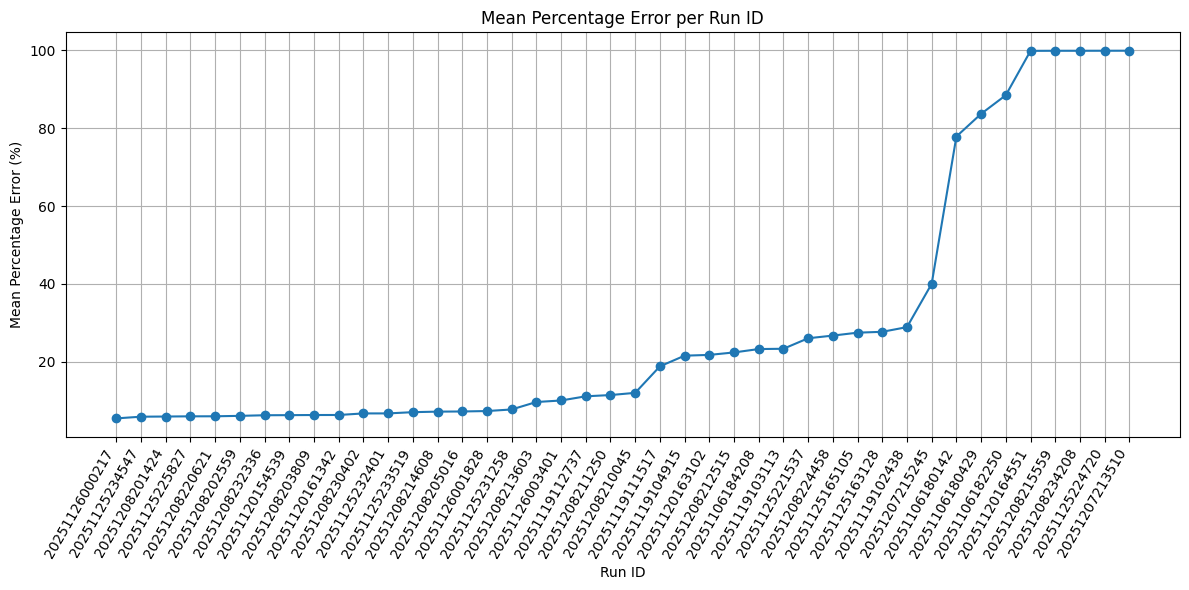

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import pymysql


conn = pymysql.connect(
    host='mysql.clarksonmsda.org',
    user='butukus',
    password='Nandu@14',
    database='butukus_Capstone'
)

query = """
SELECT 
    run_id,
    version,
    month,
    median_price_usd AS model_price,
    inserted_at
FROM ca_median_prices
ORDER BY run_id, month;
"""

df = pd.read_sql(query, conn)
conn.close()

df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").astype(str)


data = pd.read_csv("HomeMedianPrices.csv")

data["Date"] = pd.to_datetime(data["Date"]).dt.to_period("M").astype(str)
data.rename(columns={"Mon-Yr": "month"}, inplace=True)
data["month"] = data["Date"]
data.drop(columns=["Date"], inplace=True)

data = data[["month", "Los Angeles"]]
data.rename(columns={"Los Angeles": "original_price"}, inplace=True)


df_compare = df.merge(data, on="month", how="left")

df_compare = df_compare.dropna(subset=["original_price"])

df_compare["abs_error"] = (df_compare["model_price"] - df_compare["original_price"]).abs()
df_compare["pct_error"] = df_compare["abs_error"] / df_compare["original_price"] * 100

run_accuracy = df_compare.groupby("run_id").agg(
    mean_pct_error=("pct_error", "mean"),
    median_pct_error=("pct_error", "median"),
    max_pct_error=("pct_error", "max"),
    min_pct_error=("pct_error", "min"),
    data_points=("pct_error", "count")
).reset_index()

run_accuracy = run_accuracy.sort_values("mean_pct_error")

print("\n========================")
print(" Run-by-Run Accuracy Table")
print("========================")
print(run_accuracy)

plt.figure(figsize=(12, 6))
plt.plot(run_accuracy["run_id"], run_accuracy["mean_pct_error"], marker="o")
plt.title("Mean Percentage Error per Run ID")
plt.xlabel("Run ID")
plt.ylabel("Mean Percentage Error (%)")
plt.grid(True)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


**Normality Check: Distribution of Mean Prediction Errors (All Versions)**

This step evaluates whether the **mean monthly prediction errors** (Predicted − Actual), aggregated across all model versions, resemble a normal distribution within the selected time window (2023-01 to 2024-12). After filtering the comparison dataset to the specified period, the code computes an error value for each record and then aggregates to the **mean error per version per month** to reduce noise and focus on systematic behavior.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kstest, probplot

start_date = "2023-01-01"
end_date   = "2024-12-01"

sub_df = comparison_df[
    (comparison_df["month_dt"] >= start_date) &
    (comparison_df["month_dt"] <= end_date)
].copy()

sub_df["error"] = sub_df["predicted_price"] - sub_df["actual_price"]

mean_errors = (
    sub_df.groupby(["version", "month_dt"])["error"]
          .mean()
          .reset_index()
)


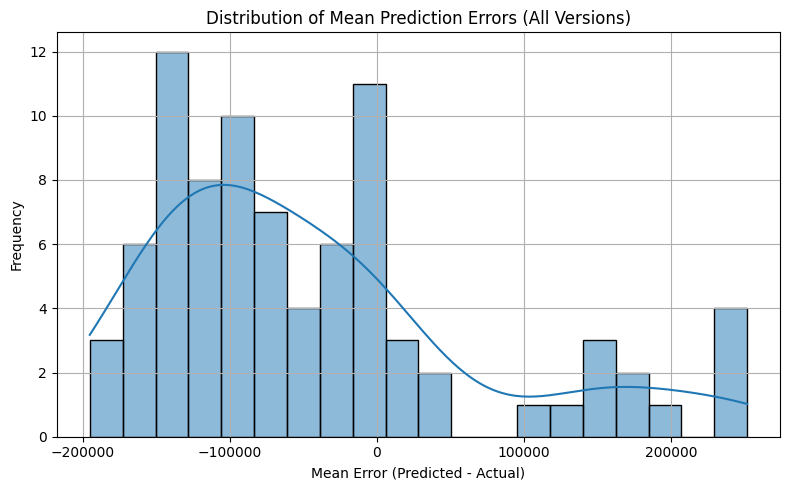

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(mean_errors["error"], bins=20, kde=True)
plt.title("Distribution of Mean Prediction Errors (All Versions)")
plt.xlabel("Mean Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()



The histogram with KDE overlay shows that the error distribution is **not symmetric and not bell-shaped**, with a heavy concentration of negative errors (underestimation) and a smaller but noticeable positive tail (overestimation). This pattern indicates that the mean errors across versions are **not normally distributed**, suggesting the presence of **systematic bias and model-specific error behavior**, and supporting the use of robust metrics (e.g., MAE/MAPE) and non-parametric comparisons rather than assuming Gaussian error structure.


**Normality Test Results: Mean Prediction Errors by Model Version**

This section evaluates whether the **mean monthly prediction errors** for each LLM version follow a normal distribution, using both the **Shapiro–Wilk test** and the **Kolmogorov–Smirnov (K–S) test**, along with summary statistics.



In [16]:
print("\nNormality Tests on Mean Errors")
print("================================")

for v in mean_errors["version"].unique():
    errs = mean_errors[mean_errors["version"] == v]["error"].dropna()
    
    shapiro_stat, shapiro_p = shapiro(errs)
    ks_stat, ks_p = kstest(
        (errs - errs.mean()) / errs.std(ddof=1),
        'norm'
    )
    
    print(f"\nVersion: {v}")
    print(f"  Shapiro-Wilk p-value: {shapiro_p:.4f}")
    print(f"  KS Test p-value:      {ks_p:.4f}")
    print(f"  Mean Error:           {errs.mean():,.0f}")
    print(f"  Std Dev:              {errs.std():,.0f}")



Normality Tests on Mean Errors

Version: llama3.1:8b
  Shapiro-Wilk p-value: 0.1040
  KS Test p-value:      0.5092
  Mean Error:           -58,986
  Std Dev:              62,834

Version: llama3.1:8b-instruct-q4_0
  Shapiro-Wilk p-value: 0.0393
  KS Test p-value:      0.6319
  Mean Error:           -76,748
  Std Dev:              56,254

Version: llama3.1:8b-instruct-q8_0
  Shapiro-Wilk p-value: 0.2290
  KS Test p-value:      0.6635
  Mean Error:           -111,565
  Std Dev:              55,366

Version: llama3.1:latest
  Shapiro-Wilk p-value: 0.1826
  KS Test p-value:      0.6489
  Mean Error:           185,646
  Std Dev:              47,506



**Interpretation by Model**

- **`llama3.1:8b`**
  - Shapiro–Wilk p-value (0.1040) and K–S p-value (0.5092) both fail to reject normality.
  - Errors are approximately normally distributed, centered around a **moderate negative bias** (~−59K USD), indicating consistent underestimation with relatively high variance.

- **`llama3.1:8b-instruct-q4_0`**
  - Shapiro–Wilk p-value (0.0393) rejects normality at the 5% level, while the K–S test does not.
  - This mixed result suggests **mild deviation from normality**, likely due to skew or tail behavior.
  - The model shows a stronger underestimation bias (~−77K USD).

- **`llama3.1:8b-instruct-q8_0`**
  - Both tests indicate no strong evidence against normality.
  - Errors are approximately normal but exhibit the **largest negative mean error** (~−112K USD), indicating systematic underprediction despite stable variance.

- **`llama3.1:latest`**
  - Normality is not rejected by either test.
  - Mean error is **strongly positive** (~+186K USD), confirming persistent overestimation with comparatively lower variance.


**Cross-Model Insights**

- While several models exhibit approximately normal error distributions, **normality does not imply accuracy**.
- All models demonstrate **systematic bias**, either underestimating (`8b`, `q4_0`, `q8_0`) or overestimating (`latest`) true prices.
- The presence of bias suggests that prediction errors are **structural rather than random**, limiting the applicability of purely parametric error assumptions.

**Key Takeaway**

Even when mean errors appear approximately normally distributed, **bias dominates model behavior**, reinforcing the need for bias correction, non-parametric evaluation, or hybrid modeling approaches when using LLM-generated numerical data.
